# KDUQ corpus: proton ay

The KDUQ corpus is a reconstruction of the experimental data used in the Koning-Delaroche global optical potential analysis, assembled from EXFOR by the supplement's authors and tabulated in Supplemental Material B.

Proton analyzing powers, dimensionless, against CM scattering angle.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/kduq_proton_ay.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('kduq', 'proton_ay')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

61 rows, 55 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,kduq,proton_ay,proton,28,14,28Si,17.80,None,O0254003,,17
1,kduq,proton_ay,proton,28,14,28Si,65.00,None,E0166009,,17
2,kduq,proton_ay,proton,28,14,28Si,80.00,None,C0084003,,17
3,kduq,proton_ay,proton,28,14,28Si,100.00,None,C0084003,,17
4,kduq,proton_ay,proton,28,14,28Si,135.00,None,C0084003,,17
5,kduq,proton_ay,proton,28,14,28Si,175.00,None,C0084003,,17
6,kduq,proton_ay,proton,28,14,28Si,180.00,None,C0152004,,17
7,kduq,proton_ay,proton,40,20,40Ca,16.00,None,C0893003,,17
8,kduq,proton_ay,proton,40,20,40Ca,26.30,None,O0490006,,17
9,kduq,proton_ay,proton,40,20,40Ca,30.05,None,O0490003,,17


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('kduq', 'proton_ay')
print(result.summary())

kduq/proton_ay
  spec rows              61
  ... marked absent      0
  ... resolved           61 / 61 (100.0%)
  measurements           54
  data points            1606
  EXFOR entries          27
  serialized             54 measurements, 1606 points
  dropped during cleaning
    O0091003: one or more data points carry no uncertainty
    O0091009: one or more data points carry no uncertainty
    O0091015: one or more data points carry no uncertainty
    O0091019: one or more data points carry no uncertainty
    O0393002: one or more data points carry no uncertainty
    O0393007: one or more data points carry no uncertainty
    O0393008: one or more data points carry no uncertainty


## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

all spec rows resolved


## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Outliers here are found by eye. A mistranscribed point shows up as a single datum an
order of magnitude away from its neighbours; a badly normalised data set shows up as a
whole curve offset from others at the same energy.

... 3 further targets not plotted


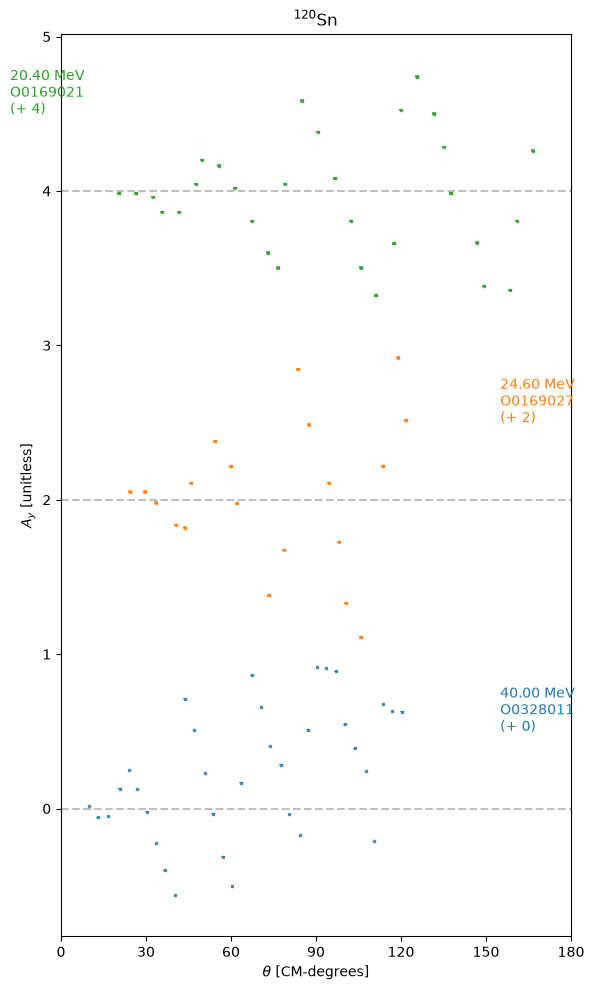

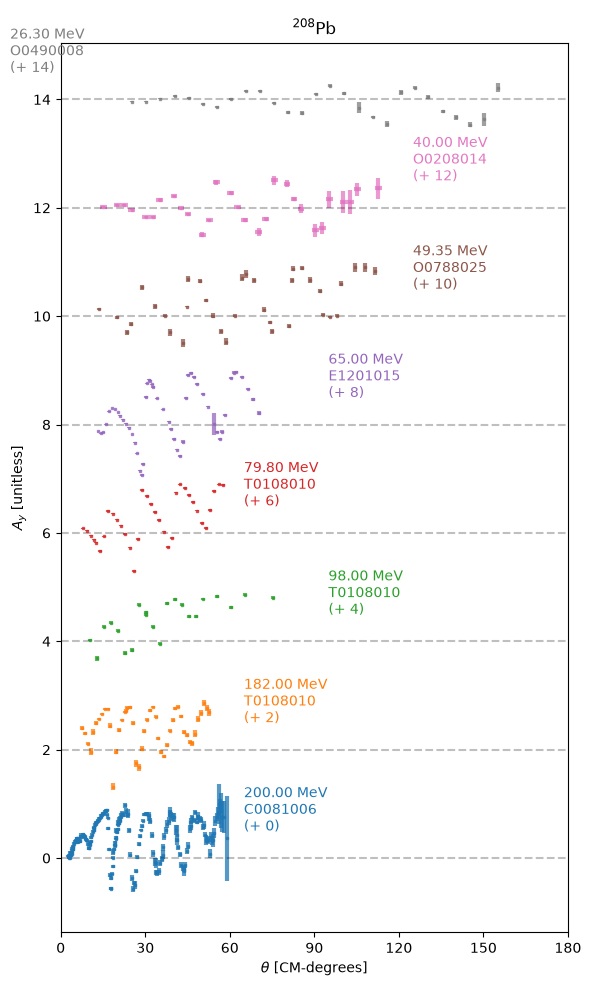

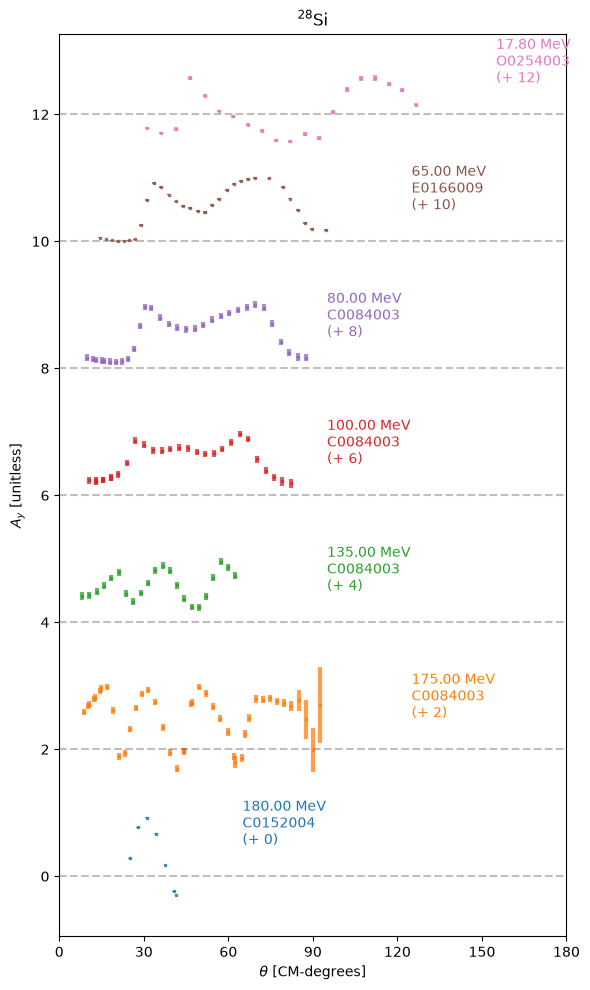

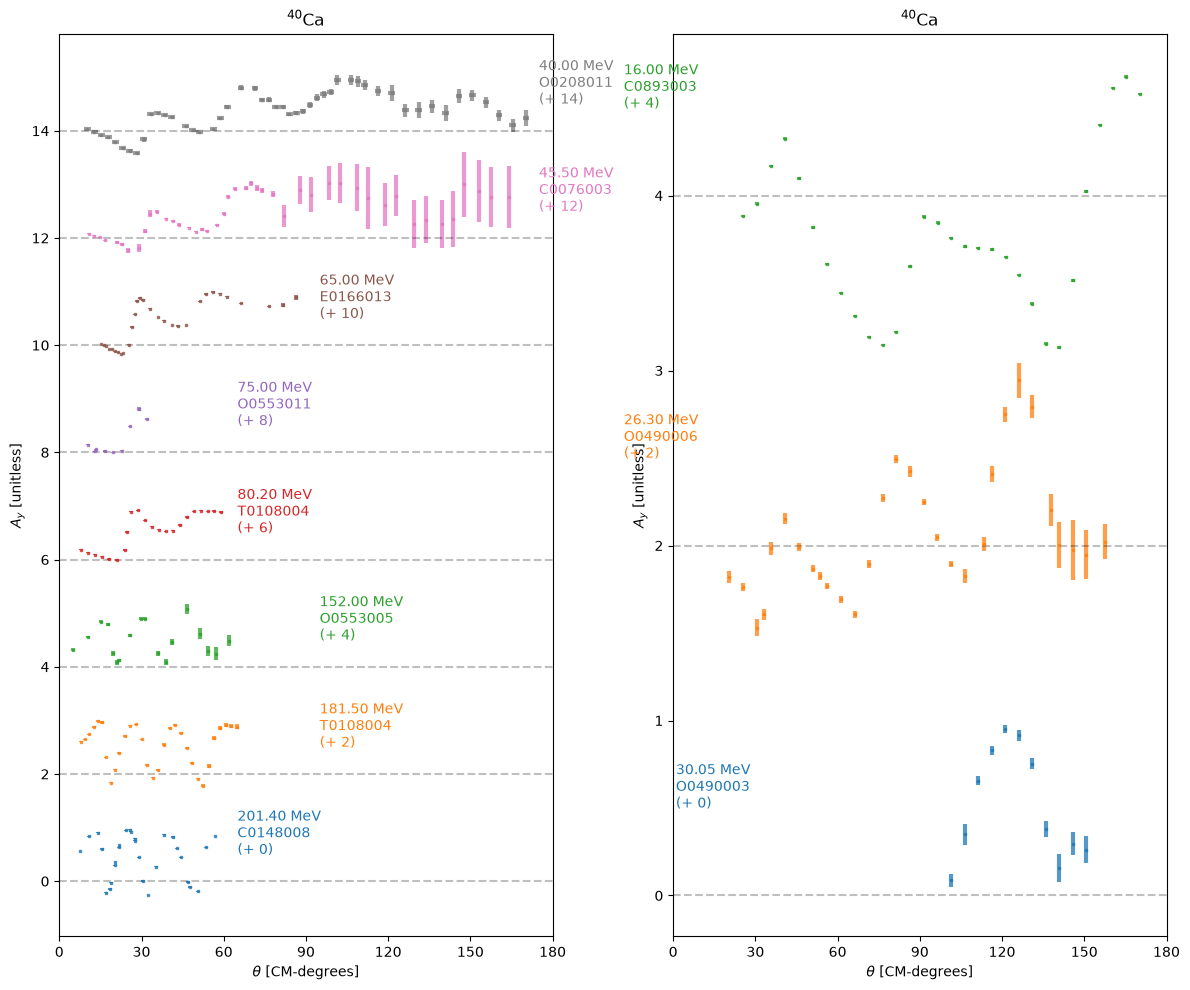

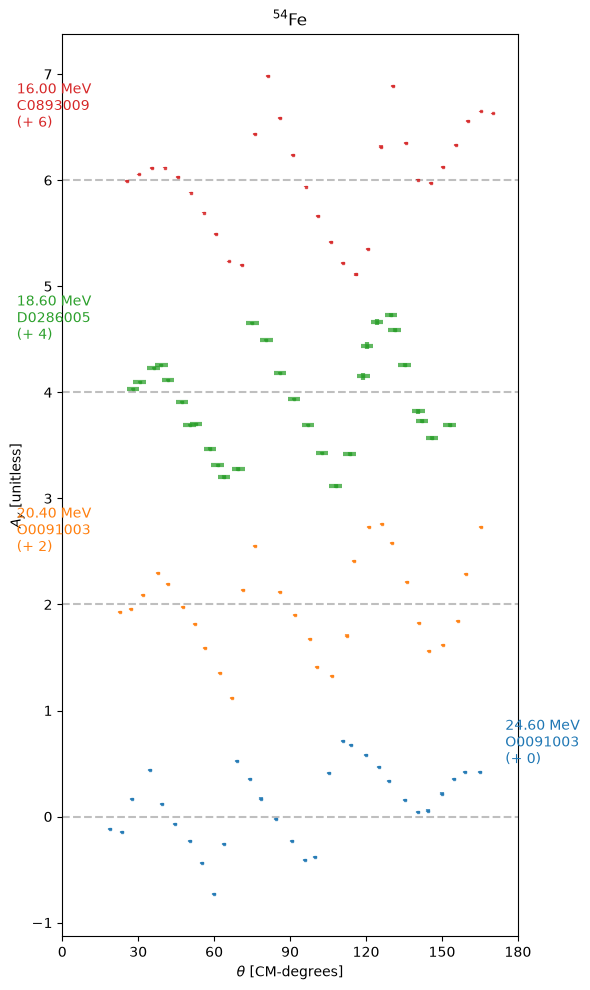

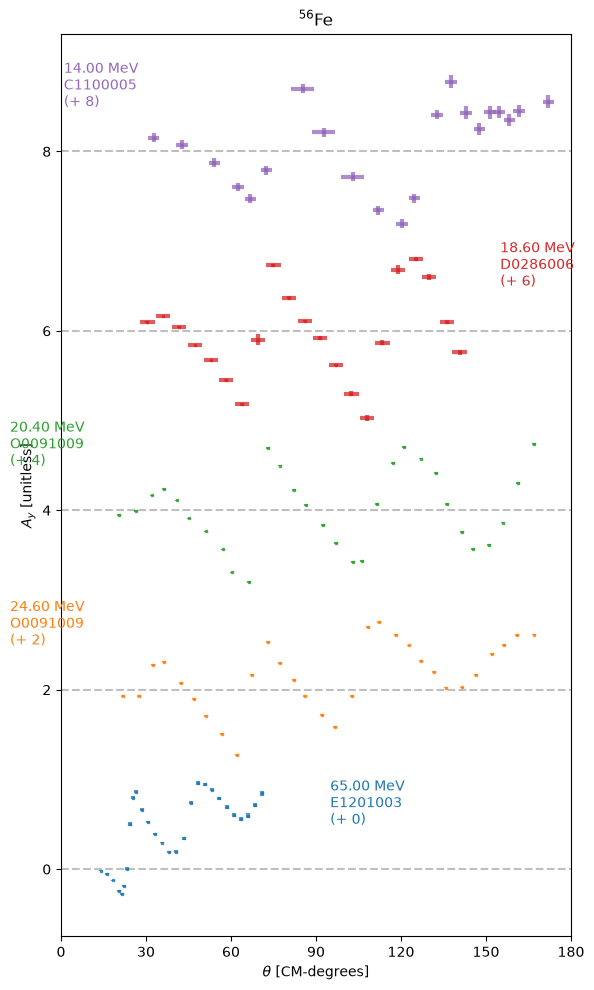

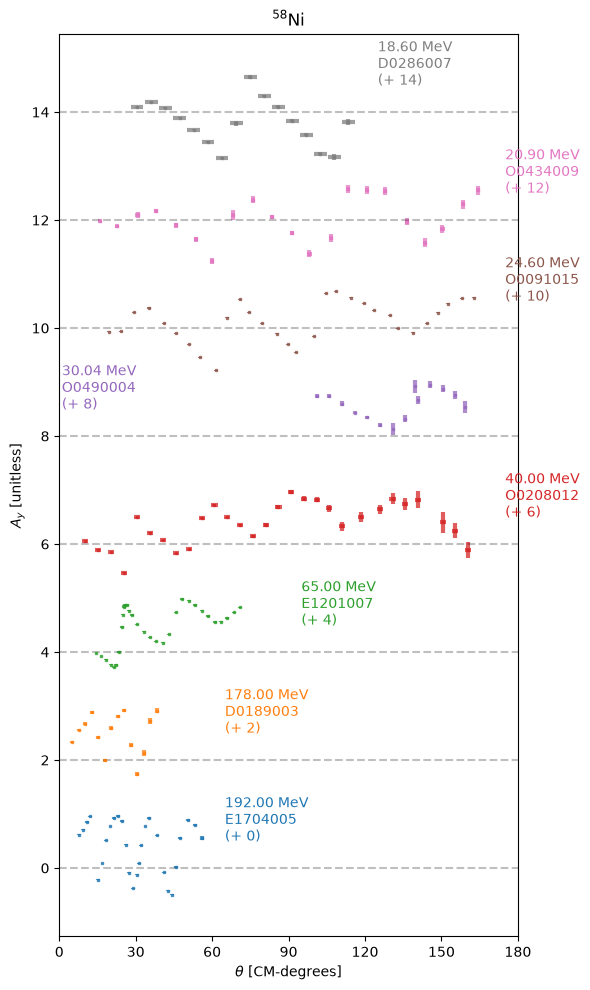

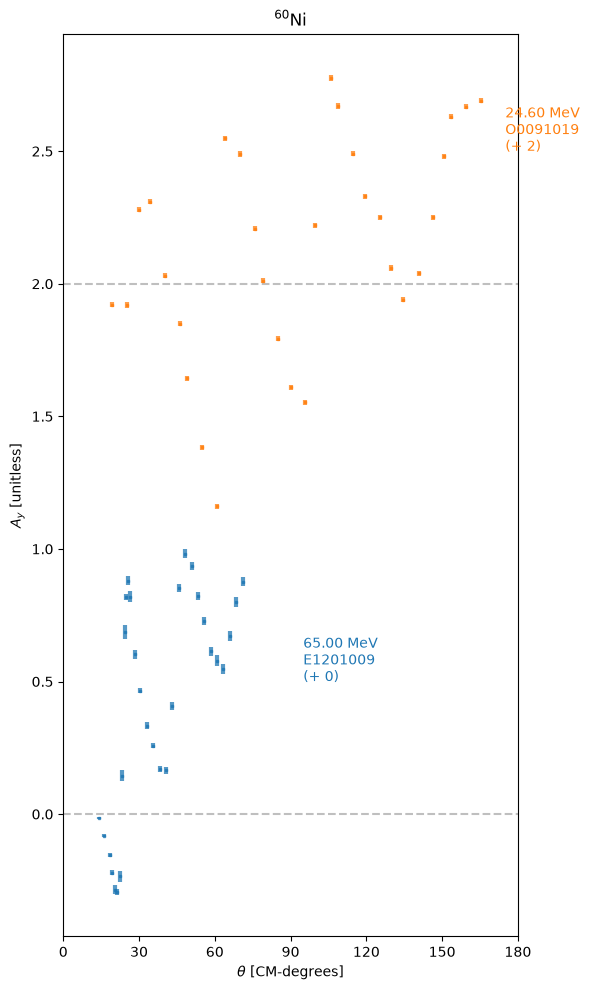

In [6]:
plotting.plot_sector(result, max_targets=8)
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 54 measurements to data/kduq/proton_ay/
